# Init

In [1]:
import torch
import numpy as np
import sympy  as sp
import plotly.graph_objects as go

# Nevergrad Imports
import nevergrad as ng

# Symxplorer Specific Imports
from   symxplorer.symbolic_exploration.domains   import ExperimentResult

from   symxplorer.designer_tools.tf_models       import Pole_Zero_TF, Second_Order_BP_TF, cascade_tf
from   symxplorer.designer_tools.visualizer      import Symbolic_Visualizer, Bode_Visualizer
from   symxplorer.designer_tools.symbolic_sizing import Symbolic_Sizing_Assist

s = sp.symbols("s")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.double

torch.set_default_dtype(dtype)
torch.set_default_device(device)
print(f'Using device: {device} and dtype: {dtype}')

Using device: cpu and dtype: torch.float64


# Load the exploration result

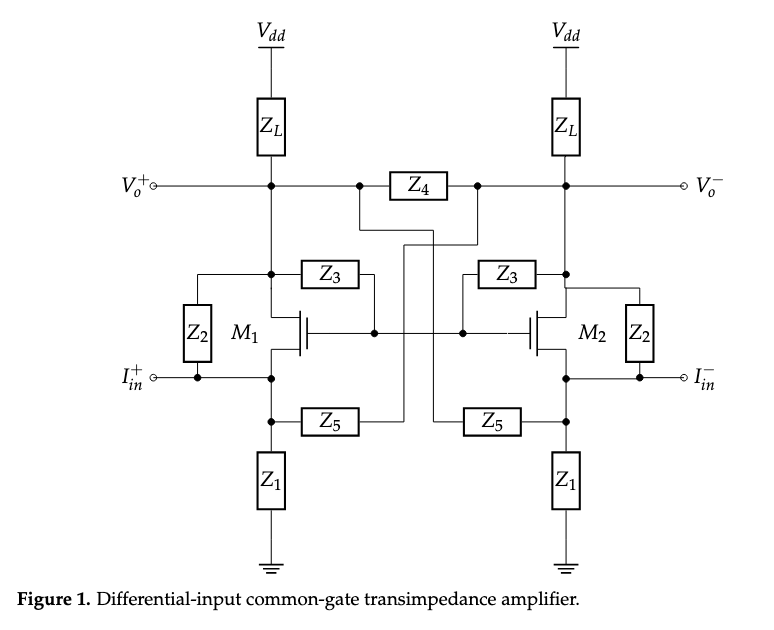

In [2]:
experiment_name = "CG_TIA_Automated_simple"
path_to_pkl = f"Runs/{experiment_name}/results.pkl"
symbolic_experiment_result = ExperimentResult(experiment_name=experiment_name)
symbolic_experiment_result = symbolic_experiment_result.load(path_to_pkl)

# Problem Setup

## Select a topology to size

In [3]:
ALLOWED_Z_CONNECTIONS = "Z1_Z2_ZL"
classifications, tf = symbolic_experiment_result.get_impedance_key(ALLOWED_Z_CONNECTIONS)
print(f"{ALLOWED_Z_CONNECTIONS} - count of tfs {len(classifications)}")
tf

Z1_Z2_ZL - count of tfs 880


(Z_1*Z_2*Z_L*g_m + Z_1*Z_L)/(Z_1*Z_2*g_m + Z_1 + Z_2 + Z_L)

In [4]:
FILTER_TYPE = "BP" # should switch to using enums
classifications_filtered = symbolic_experiment_result.get_filter_types(fTypes=[FILTER_TYPE], zCombos=ALLOWED_Z_CONNECTIONS)
len(classifications_filtered)

6

In [5]:
sel = 1
tf_to_size = classifications_filtered[sel]
print(f"Selected Z-combo is\n{tf_to_size.zCombo}")
print(f"numer order = {tf_to_size.tf_numer_order}\ndenom_order = {tf_to_size.tf_denom_order}\nfilter_id: {tf_to_size.filter_id}")
tf_to_size.transferFunc

Selected Z-combo is
(R_1, R_2, oo, oo, oo, L_L*R_L*s/(C_L*L_L*R_L*s**2 + L_L*s + R_L))
numer order = 1
denom_order = 2
filter_id: 2647


s*(L_L*R_1*R_2*R_L*g_m + L_L*R_1*R_L)/(R_1*R_2*R_L*g_m + R_1*R_L + R_2*R_L + s**2*(C_L*L_L*R_1*R_2*R_L*g_m + C_L*L_L*R_1*R_L + C_L*L_L*R_2*R_L) + s*(L_L*R_1*R_2*g_m + L_L*R_1 + L_L*R_2 + L_L*R_L))

### Filter Parameters

In [6]:
print(f"filter parameters are {tf_to_size.parameters.keys()}")

filter parameters are dict_keys(['Q', 'wo', 'bandwidth', 'K_LP', 'K_HP', 'K_BP', 'Qz', 'Wz'])


In [7]:
# Q
tf_to_size.parameters.get("Q", None)

(sqrt(C_L)*R_1*R_2*R_L*g_m + sqrt(C_L)*R_1*R_L + sqrt(C_L)*R_2*R_L)/(sqrt(L_L)*R_1*R_2*g_m + sqrt(L_L)*R_1 + sqrt(L_L)*R_2 + sqrt(L_L)*R_L)

In [8]:
# WO
tf_to_size.parameters.get("wo", None)

1/(sqrt(C_L)*sqrt(L_L))

In [9]:
# bandwidth
tf_to_size.parameters.get("bandwidth", None)

(sqrt(L_L)*R_1*R_2*g_m + sqrt(L_L)*R_1 + sqrt(L_L)*R_2 + sqrt(L_L)*R_L)/(sqrt(C_L)*sqrt(L_L)*(sqrt(C_L)*R_1*R_2*R_L*g_m + sqrt(C_L)*R_1*R_L + sqrt(C_L)*R_2*R_L))

In [10]:
# K_BP
tf_to_size.parameters.get("K_BP", None)

(R_1*R_2*R_L*g_m + R_1*R_L)/(R_1*R_2*g_m + R_1 + R_2 + R_L)

### Symbolic Visualization

In [11]:
sym_vis = Symbolic_Visualizer(filter_classification=tf_to_size)
sym_vis.is_defined_numerically()

False

In [12]:
sym_vis.get_parameters()

['C_L', 'L_L', 'R_1', 'R_2', 'R_L', 'g_m']

In [13]:
sym_vis.set_equal_r()

s*(L_L*R**3*g_m + L_L*R**2)/(R**3*g_m + 2*R**2 + s**2*(C_L*L_L*R**3*g_m + 2*C_L*L_L*R**2) + s*(L_L*R**2*g_m + 3*L_L*R))

In [14]:
sym_vis.get_parameters()

['C_L', 'L_L', 'R', 'g_m']

In [15]:
sym_vis.reset_params()
sym_vis.set_params(param_str_to_value={
    "R" : 1e3, # used in case of equal R
    "C" : 1e-12, # used in case of equal C
    "R_1" : 1e3,
    "R_2" : 1e3,
    "C_L" : 100e-12,
    "L_L" : 1e-9,
    # "g_m" : 20e-3,
})
sym_vis.params_to_value

C does not exist in the list of free symbols. Choose from dict_keys(['C_L', 'L_L', 'R', 'g_m'])
R_1 does not exist in the list of free symbols. Choose from dict_keys(['C_L', 'L_L', 'R', 'g_m'])
R_2 does not exist in the list of free symbols. Choose from dict_keys(['C_L', 'L_L', 'R', 'g_m'])


{s: 2*I*pi*f, R: 1000.0, C_L: 1e-10, L_L: 1e-09}

In [16]:
magnitude_expr, phase_expr, H_numeric = sym_vis.get_bode_expression()
H_numeric

2*I*pi*f*(1.0*g_m + 0.001)/(-4*pi**2*f**2*(1.0e-10*g_m + 2.0e-13) + 2*I*pi*f*(0.001*g_m + 3.0e-6) + 1000000000.0*g_m + 2000000.0)

In [17]:
sym_vis.get_filter_param()

['K_BP', 'K_HP', 'K_LP', 'Q', 'bandwidth', 'wo']

In [18]:
expr, val = sym_vis.eval_filter_parameter(param_name="K_BP", num_of_decimals=3)
# expr
expr.simplify()

Cannot numerically evaluate the TF since the design parameters are not resolved. provided {s: 2*I*pi*f, R: 1000.0, C_L: 1e-10, L_L: 1e-09} but need {C_L, s, L_L, R, g_m}


(1000000000.0*g_m + 1000000.0)/(1000000.0*g_m + 3000.0)

In [19]:
expr, val = sym_vis.eval_filter_parameter(param_name="wo", num_of_decimals=3)
# expr / (2*sp.pi)
val / (2*np.pi)

Cannot numerically evaluate the TF since the design parameters are not resolved. provided {s: 2*I*pi*f, R: 1000.0, C_L: 1e-10, L_L: 1e-09} but need {C_L, s, L_L, R, g_m}


nan

In [20]:
sym_vis.set_params(param_str_to_value={
    "g_m" : 20e-3,
})
expr, val = sym_vis.eval_filter_parameter(param_name="K_BP", num_of_decimals=3)
expr

913.043478260870

printing parameters:
-------------------------------------
	K_BP:	9.130e+02
	K_HP:	0.000e+00
	K_LP:	0.000e+00
	Q:	3.025e+02
	bandwidth:	1.045e+07
	f:	5.033e+08
-------------------------------------


Calculating Phases: 100%|██████████| 200/200 [00:01<00:00, 113.33it/s]


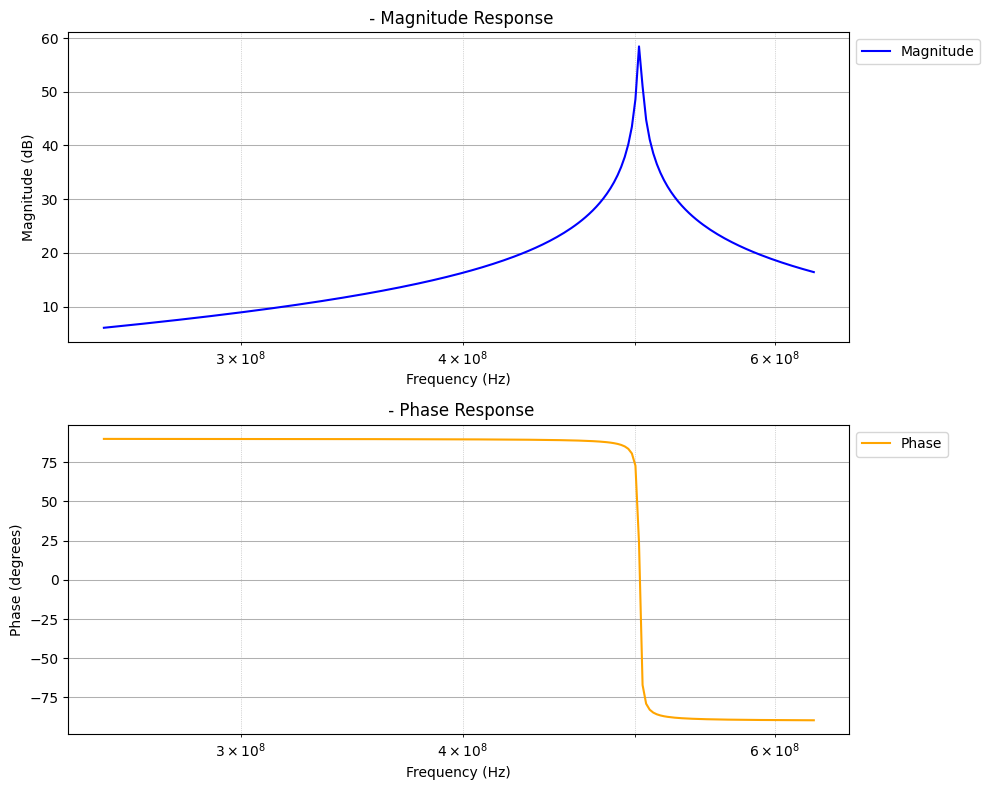

In [21]:
sym_vis.print_filter_parameters()
sym_vis.visualize(start_freq_order=8.4, end_freq_order=8.8, num_of_points=200)

## Define the target TF

In [22]:
frequencies = torch.logspace(5, 10, 20000)

fc = 1e8
q  = 1
k_bp = 1e3
target_tf_obj = Second_Order_BP_TF(q=q, fc=fc, k_bp=k_bp)
target_tf     = target_tf_obj.get_tf()
# target_tf = cascade_tf(list_of_tfs=[tf1, tf2], dc_gain_multiplier=1)

k_bp_db = 20*np.log10(k_bp)

Calculating Phases: 100%|██████████| 200/200 [00:00<00:00, 472.07it/s]


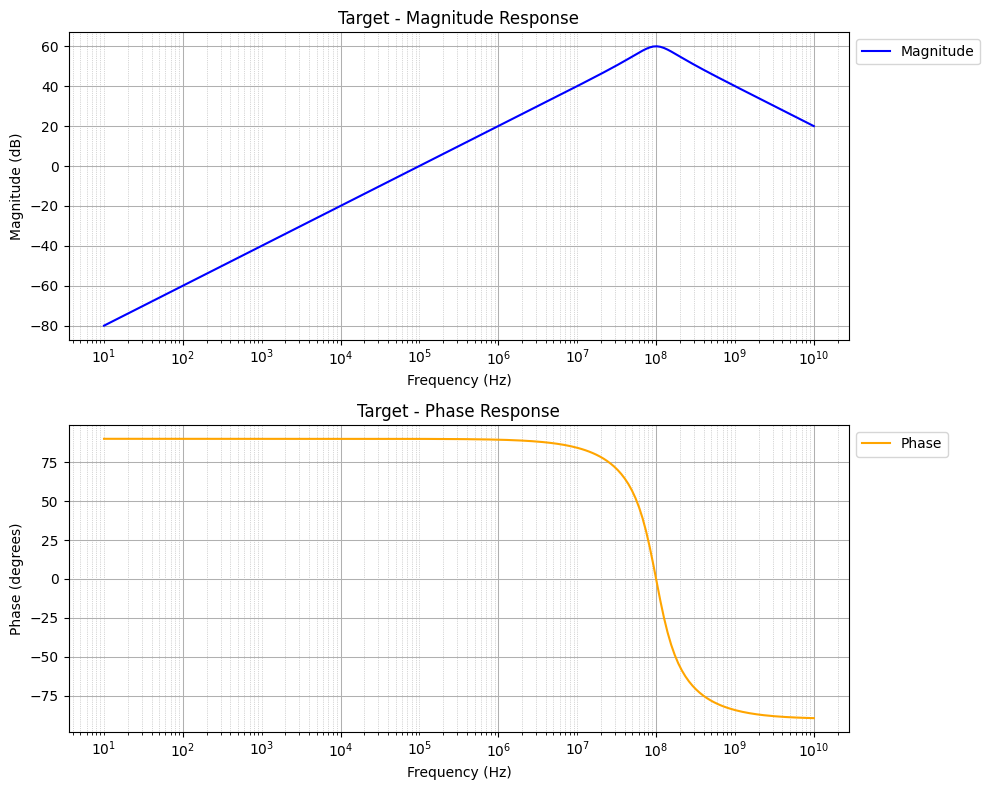

In [23]:
taregt_vis = Symbolic_Visualizer(tf=target_tf)
taregt_vis.visualize(start_freq_order=1, end_freq_order=10, num_of_points=200, title="Target")

In [24]:
# Define range
lower_bound = 1e6
upper_bound = 12e6

# Generate binary mask
weighted_frequencies = torch.where((frequencies >= lower_bound) & (frequencies <= upper_bound), 1, 1)

# Direct Solving via Symbolic Solutions

In [25]:
assist = Symbolic_Sizing_Assist(
    filter_classification=tf_to_size
)

In [26]:
assist.get_metrics()

['Q', 'wo', 'bandwidth', 'K_BP']

In [27]:
assist.remove_metric("Q")
# assist.remove_metric("bandwidth")

True

In [28]:
assist.get_design_variables()

['C_L', 'R_2', 'L_L', 'R_L', 'g_m', 'R_1']

In [29]:
assist.get_problem_space()

(0, 6, 3)

In [30]:
assist.is_overconstrained()

False

In [31]:
# assist.get_jacobian_of_metrics()

In [32]:
# assist.sub_val_design_vars_in_metrics({
#     "R_L" : 10e3,
#     "R_2" : 10e3,
# })

In [33]:
assist.relax_design_variable(name="L_L")
assist.relax_design_variable(name="C_L")
assist.relax_design_variable(name="g_m")

True

In [34]:
sol = assist.solve_inverse()
assist.design_var_in_terms_of_metrics_dict # this is the same as sol of solve_inverse method

{R_1: -C_L*K_BP*R_L*bandwidth/(C_L*K_BP*R_L*bandwidth*g_m - C_L*R_L*bandwidth - R_L*g_m + 1),
 R_2: R_L*(-C_L*K_BP*bandwidth + 1)/(C_L*R_L*bandwidth - 1)}

In [35]:
assist.metric_equations # Created by solve_inverse method

[Eq(wo, 1/(sqrt(C_L)*sqrt(L_L))),
 Eq(bandwidth, (R_1*R_2*g_m + R_1 + R_2 + R_L)/(C_L*R_L*(R_1*R_2*g_m + R_1 + R_2))),
 Eq(K_BP, R_1*R_L*(R_2*g_m + 1)/(R_1*R_2*g_m + R_1 + R_2 + R_L))]

In [36]:
assist.sub_val_metrics({
    "bandwidth" : 10e6,
    "wo": 1e9,
    "K_BP" : 1e3,

    # "C_L" : 10e-12
})
assist.design_var_in_terms_of_metrics_dict

{R_1: -10000000000.0*C_L*R_L/(10000000000.0*C_L*R_L*g_m - 10000000.0*C_L*R_L - R_L*g_m + 1),
 R_2: R_L*(1 - 10000000000.0*C_L)/(10000000.0*C_L*R_L - 1)}

In [37]:
assist.sub_val_design_vars_in_metrics({
    "C_L" : 10e-12,
    "R_L" : 10e3,
    "g_m" : 20e-3,
})
assist.design_var_in_terms_of_metrics_dict

{R_1: 5.55555555555556, R_2: -8.10647932926689e+19}

In [38]:
list(assist.design_variables_dict.values())

[R_2, R_L, R_1]